In [1]:
import matplotlib.pyplot as plt
from utils.helpers import *


# -- Set a GPS time:
t0 = 1126259462.4    # -- GW150914
center = int(t0)  #-- Round GPS time to nearest second
#-- Choose detector as H1, L1, or V1
detector = 'H1'
strain = unpickle_me_this("/phase_I/partial_successful_reconstruct_and_where_is_the_signal/corr/GW150914_strain.pickle")

data = 1e19 * strain.value
# data = strain.value


zero_time = 1126259446  # I got this zero time by looking at the caption of the figure produced by strain.plot().
time = np.array(strain.times) - zero_time  # in seconds
onset = t0 - zero_time

%matplotlib inline

In this notebook, I show that using my own welch averaging and bandpassing functions that:

- The signal reveals itself optically in the whitened and bandpassed data if the power spectrum is estimated by neglecting the signal window in the average
- The signal reveals itself optically in the whitened and bandpassed data if the power spectrum is estimated by *also including* the signal window in the average
- The signal reveals itself optically in the Wigner-Function when giving the whitened (not-bandpassed!) data as input.

In [4]:
def notebook_me_this(full_x, full_y, plot_ps=False, plot_wh_and_bp_data=False,leave_out=None, debug=False,
                     starting_point_of_window=15.5, data_to_use_in_stress_calculation="whitened", plot_stress=False,
                     plot_frequency_marginalized_stress=False, title_for_stress_mat=None):

    time = full_x
    data = full_y

    L=2
    freqs, power_spectrum = welch_average(x=time, y=data, L=L, leave_out=leave_out, debug=debug, output_on_full_harmonic_domain=True)

    if plot_ps:
        tmp = int(len(freqs)/2+1)  # plot only positive frequencies
        _ = plt.figure()
        plt.plot(freqs[:tmp], power_spectrum.val[:tmp], "b-")
        plt.loglog()
        usual_plot(xl="Unique k lengths ", yl="Power")



    dt = time[1] - time[0]
    N = np.int64(L/dt) + 1  # np.int64(L/dt) is the number of intervals and there are +1 more sample points than intervals

    subwindow_init = np.argmin(np.abs(time-starting_point_of_window))  # signal window if 15.5 and L = 2

    subwindow_idcs = np.arange(subwindow_init, subwindow_init + N)

    subwindow_data = data[subwindow_idcs]
    subwindow_time = time[subwindow_idcs]


    print(" N", N, len(subwindow_idcs), len(subwindow_data), len(power_spectrum.val))
    wh_data = whiten(y=subwindow_data, amp=np.sqrt(power_spectrum.val))
    wh_bp_data = bandpass(x=subwindow_time, y=wh_data)


    if plot_wh_and_bp_data:
        fig, axs = plt.subplots(1, 3, figsize=(12, 4))
        axs[0].plot(subwindow_time, subwindow_data)
        axs[1].plot(subwindow_time, wh_data)
        axs[2].plot(subwindow_time, wh_bp_data)

        axs[0].set_title("Raw data")
        axs[1].set_title("Whitened data")
        axs[2].set_title("Whitened and Bandpass data")

        plt.show()

    time_space = ift.RGSpace(shape=(N,), distances=dt)
    if data_to_use_in_stress_calculation == "whitened":
        data_field = ift.Field(dt_(time_space), val=wh_data)
    elif data_to_use_in_stress_calculation == "whitened and bandpassed":
        data_field = ift.Field(dt_(time_space), val=wh_bp_data)
    elif data_to_use_in_stress_calculation == "normal":
        data_field = ift.Field(dt_(time_space), val=data)
    else:
        raise ValueError("data_to_use_in_stress_calculation must be 'whitened', 'whitened and bandpassed' or 'normal'")

    stress, t_dual, f = Stress(data_field)
    wigner_mat = np.abs(stress.real)
    print("\t\t btw I am taking the absolute value to get rid of negative stress values")
    if plot_stress:
        # wigner_mat[wigner_mat<5e5] = 0
        if title_for_stress_mat is None:
            tl = f" : The {data_to_use_in_stress_calculation} data carries a signal imprint"
        else:
            tl = title_for_stress_mat
        visualize_stress(wigner_mat, rows=f, cols=t_dual+min(subwindow_time), tl=tl)

    marginalized = np.sum(wigner_mat, axis=0)

    if plot_frequency_marginalized_stress:
        _ = plt.figure()
        plt.plot(t_dual+subwindow_time[0], marginalized)
        usual_plot(yl="Stress", title="Frequency-Marginalized stress evolution")

    return (wigner_mat, t_dual+subwindow_time[0], f), marginalized



Constructing 16 windows over which we average.

 N 8193 8193 8193 8193


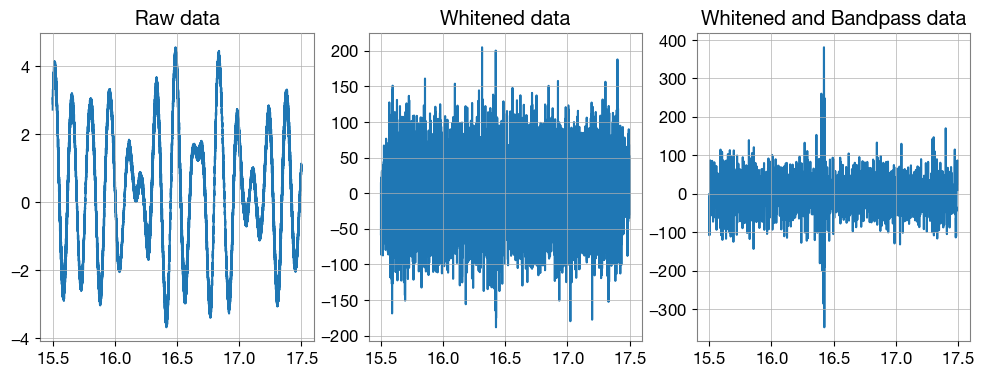


Calculating stress...
	 Calculating zeta plus
	 Calculating zeta minus
	 Calculating zeta plus in Fourier space
	 Calculating zeta minus in Fourier space
	 Calculating Phi matrix
	 Fourier-Transforming columns of Phi matrix
	 ... Done
✔ Mean imaginary part of stress field is smaller than 1e-10 threshold (1.793520447630704e-13) 
		 btw I am taking the absolute value to get rid of negative stress values


In [5]:
(wigner_mat_signal, t_dual_signal, f_signal), marginalized_signal = notebook_me_this(full_x=time, full_y=data, plot_ps=False, plot_wh_and_bp_data=True, plot_stress=False, plot_frequency_marginalized_stress=False, data_to_use_in_stress_calculation="whitened and bandpassed")

In [ ]:
(wigner_mat_off_signal, t_dual_off_signal, f_off_signal), marginalized_off_signal = notebook_me_this(full_x=time, full_y=data, plot_ps=False, plot_wh_and_bp_data=True, plot_stress=False, plot_frequency_marginalized_stress=False, starting_point_of_window=10, title_for_stress_mat="Off-signal window whitened data")

In [ ]:

off_signal_starts = np.arange(1.5, 18, 2)  # including signal in the mean!! Hopefully gets diluted

marginalized_off_signal_stress = []

for start in off_signal_starts:
    (wigner_mat_off_signal, t_dual_off_signal, f_off_signal), marginalized_off_signal = notebook_me_this(full_x=time, full_y=data, plot_ps=False, plot_wh_and_bp_data=False, plot_stress=False, plot_frequency_marginalized_stress=False, starting_point_of_window=start)
    marginalized_off_signal_stress.append(marginalized_off_signal)


In [ ]:
avg_marginalized_off_signal_stress = np.mean(marginalized_off_signal_stress, axis=0)
std_marginalized_off_signal_stress = np.std(marginalized_off_signal_stress, axis=0)

_ = plt.figure(figsize=(12, 4))
plt.errorbar(t_dual_signal, np.abs(marginalized_signal-avg_marginalized_off_signal_stress), yerr=std_marginalized_off_signal_stress, label="residual between mean and signal sample", color="blue", ecolor="lightblue")
# plt.plot(t_dual_signal, np.abs(marginalized_signal-avg_marginalized_off_signal_stress), label="residual between mean and signal sample")
# plt.plot(t_dual_signal, np.abs(marginalized_off_signal_stress[0]-avg_marginalized_off_signal_stress), label="residual between mean and one sample")
plt.legend()
plt.show()